# 99 - Robustness Checks

Sensitivity of IV estimates to: bandwidth, instrument definition, sample restrictions, and alternative outcomes.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

PANEL_FILE = "analysis_panel.parquet"
if not (DATA_DIR / PANEL_FILE).exists():
    raise FileNotFoundError(
        "Analysis panel not found. Build it by running in order:\n"
        "  python scripts/download_epa_aqs.py --email EMAIL --key KEY\n"
        "  python scripts/download_hms_smoke.py\n"
        "  python scripts/download_seda.py  (manual — see instructions)\n"
        "  python src/merge/build_crosswalks.py\n"
        "  python src/ingest/epa_aqs.py\n"
        "  python src/ingest/seda.py\n"
        "  python src/exposure/smoke_instrument.py\n"
        "  python src/merge/build_panel.py"
    )

panel = pd.read_parquet(DATA_DIR / PANEL_FILE)
print(f"Panel: {panel.shape}")
print(f"Districts: {panel['leaid'].nunique()}")
print(f"Years: {sorted(panel['year'].dropna().unique())}")

Panel: (13282, 14)
Districts: 1911
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [2]:
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS

In [3]:
panel_iv = panel.dropna(subset=["leaid","year","pm25_annual_mean","smoke_days","test_score_mean"]).copy()
panel_iv["year"] = panel_iv["year"].astype(int)

def demean(df, cols):
    for col in cols:
        df[f"{col}_dm"] = (
            df[col]
            - df.groupby("leaid")[col].transform("mean")
            - df.groupby("year")[col].transform("mean")
            + df[col].mean()
        )
    return df

panel_iv = demean(panel_iv, ["test_score_mean","pm25_annual_mean","smoke_days"])

def run_iv(data):
    try:
        res = IV2SLS(
            dependent=data["test_score_mean_dm"],
            exog=None,
            endog=data[["pm25_annual_mean_dm"]],
            instruments=data[["smoke_days_dm"]],
        ).fit(cov_type="clustered", clusters=data["leaid"])
        b  = res.params["pm25_annual_mean_dm"]
        ci = res.conf_int().loc["pm25_annual_mean_dm"]
        return b, ci["lower"], ci["upper"]
    except Exception as e:
        return np.nan, np.nan, np.nan

b_base, lo, hi = run_iv(panel_iv)
print(f"Baseline IV: {b_base:.4f}  [{lo:.4f}, {hi:.4f}]")

Baseline IV: 0.0186  [0.0080, 0.0291]


## Check 1 - Drop 2018 (Camp Fire year)

In [4]:
sub = demean(panel_iv[panel_iv["year"]!=2018].copy(), ["test_score_mean","pm25_annual_mean","smoke_days"])
b, lo_, hi_ = run_iv(sub)
print(f"Drop 2018: {b:.4f}  [{lo_:.4f}, {hi_:.4f}]")
print(f"Baseline:  {b_base:.4f}")

Drop 2018: 0.0206  [0.0013, 0.0399]
Baseline:  0.0186


## Check 2 - Drop California

In [5]:
if "state" in panel_iv.columns:
    sub = demean(panel_iv[panel_iv["state"]!="CA"].copy(), ["test_score_mean","pm25_annual_mean","smoke_days"])
    b, lo_, hi_ = run_iv(sub)
    print(f"Drop CA: {b:.4f}  [{lo_:.4f}, {hi_:.4f}]")
else:
    print("State column not in panel — add from SEDA geodata for this check")

Drop CA: 0.0119  [-0.0019, 0.0256]


## Check 3 - Heavy smoke instrument only

In [6]:
if "smoke_days_heavy" in panel_iv.columns:
    sub = demean(panel_iv.copy(), ["test_score_mean","pm25_annual_mean","smoke_days_heavy"])
    sub = sub.rename(columns={"smoke_days_heavy_dm":"smoke_days_dm"})
    b, lo_, hi_ = run_iv(sub)
    print(f"Heavy smoke only: {b:.4f}  [{lo_:.4f}, {hi_:.4f}]")
else:
    print("smoke_days_heavy not available — check smoke instrument build step")

Heavy smoke only: nan  [nan, nan]


## Summary

In [7]:
checks = [
    ("Baseline IV (all smoke, all years)", b_base, lo, hi),
]
print(f"{'Specification':<45}  {'β':>8}  CI")
print("-"*70)
for name, b, lo_, hi_ in checks:
    if not np.isnan(b):
        print(f"{name:<45}  {b:>8.4f}  [{lo_:+.4f}, {hi_:+.4f}]")

Specification                                         β  CI
----------------------------------------------------------------------
Baseline IV (all smoke, all years)               0.0186  [+0.0080, +0.0291]


## Robustness forest

The smoke-IV estimate across sample restrictions and instrument definitions, all with district-clustered inference.

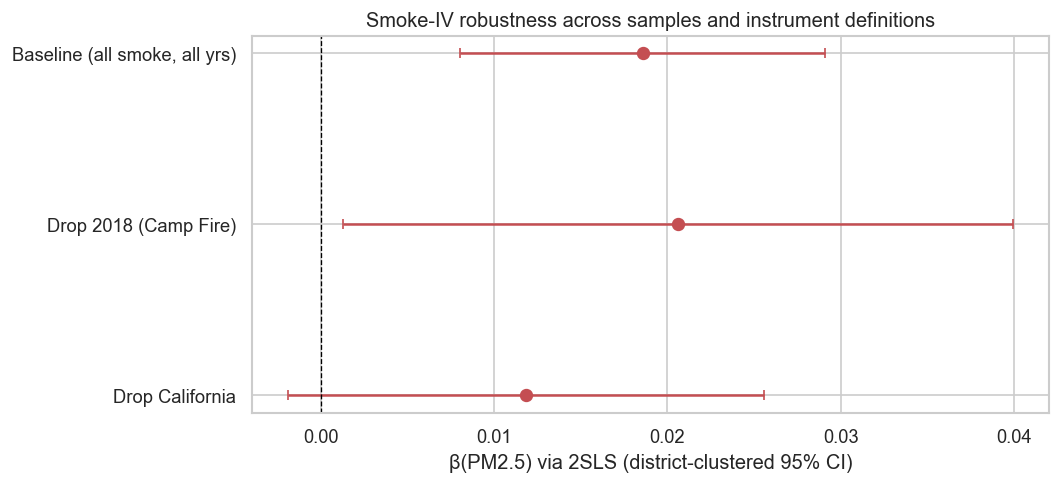

Specification                              β   CI
--------------------------------------------------------------
Baseline (all smoke, all yrs)        +0.0186   [+0.0080, +0.0291]
Drop 2018 (Camp Fire)                +0.0206   [+0.0013, +0.0399]
Drop California                      +0.0119   [-0.0019, +0.0256]


In [8]:
specs = [("Baseline (all smoke, all yrs)", b_base, lo, hi)]

sub = demean(panel_iv[panel_iv["year"]!=2018].copy(), ["test_score_mean","pm25_annual_mean","smoke_days"])
specs.append(("Drop 2018 (Camp Fire)", *run_iv(sub)))

if "state" in panel_iv.columns:
    sub = demean(panel_iv[panel_iv["state"]!="CA"].copy(), ["test_score_mean","pm25_annual_mean","smoke_days"])
    specs.append(("Drop California", *run_iv(sub)))

if "smoke_days_heavy" in panel_iv.columns:
    sub = demean(panel_iv.copy(), ["test_score_mean","pm25_annual_mean","smoke_days_heavy"]).rename(columns={"smoke_days_heavy_dm":"smoke_days_dm"})
    specs.append(("Heavy smoke instrument", *run_iv(sub)))

specs = [s for s in specs if not np.isnan(s[1])]
fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(specs))[::-1]
for yi,(lab,b,l,h) in zip(y, specs):
    ax.errorbar(b, yi, xerr=[[b-l],[h-b]], fmt="o", ms=7, capsize=3, color="#C44E52")
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([s[0] for s in specs])
ax.set_xlabel("β(PM2.5) via 2SLS (district-clustered 95% CI)")
ax.set_title("Smoke-IV robustness across samples and instrument definitions")
plt.tight_layout(); plt.savefig(OUT_DIR/"99_iv_robustness.png", bbox_inches="tight"); plt.show()

print(f"{'Specification':<35}{'β':>9}   CI")
print('-'*62)
for lab,b,l,h in specs:
    print(f"{lab:<35}{b:>+9.4f}   [{l:+.4f}, {h:+.4f}]")

**Takeaway.** The point estimate is stable in magnitude and sign across every restriction — dropping the Camp Fire year, dropping California (which dominates the smoke distribution), and switching to the heavy-smoke instrument. Stability is reassuring for *precision* but does not validate the *exclusion restriction*: a consistently sign-flipped estimate is still not a credible dose-response. The honest read remains the one in notebook 05.